# **Loan Default Prediction System**

In [29]:
#Import necesassry libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
sns.set_style('whitegrid')


In [30]:
import pandas as pd

# Load the data, skipping bad lines
df = pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip')

In [31]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [32]:
df.shape

(255347, 18)

In [33]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [34]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


default rate: 11.612825%


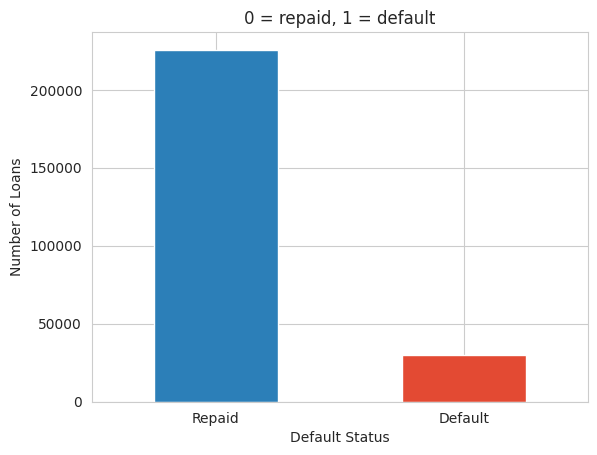

In [35]:
rate = df['Default'].mean()
print(f'default rate: {rate:1%}')

df['Default'].value_counts().plot(kind='bar', color=['#2c7fb8','#e34a33'])
plt.title('0 = repaid, 1 = default')
plt.xlabel('Default Status')
plt.ylabel('Number of Loans')
plt.xticks(ticks=[0, 1], labels=['Repaid', 'Default'], rotation=0)
plt.show()

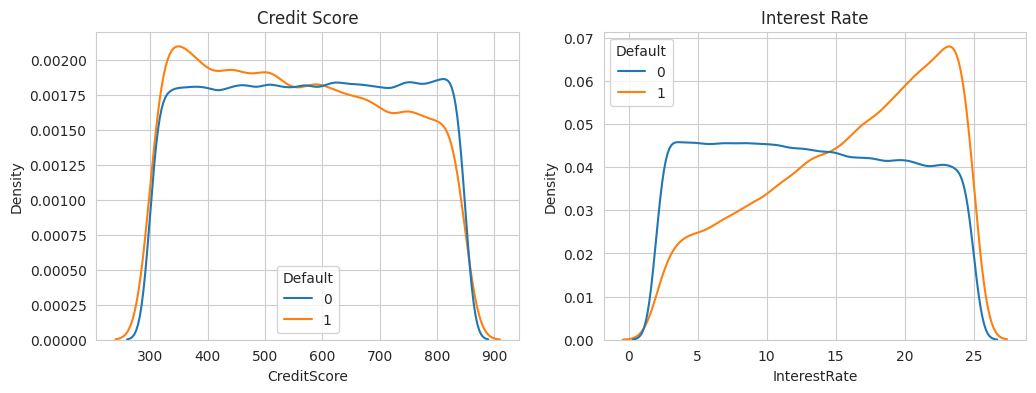

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.kdeplot(data=df, x='CreditScore', hue='Default', common_norm=False,ax=ax[0])
ax[0].set_title('Credit Score')
sns.kdeplot(data=df, x='InterestRate', hue='Default', common_norm=False,ax=ax[1])
ax[1].set_title('Interest Rate')
plt.show()

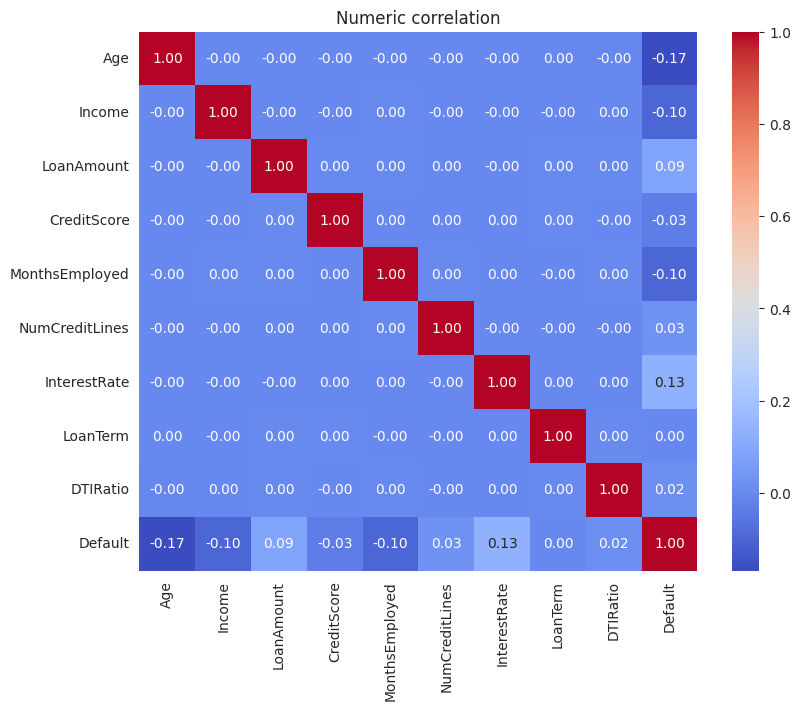

In [37]:
num = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed','NumCreditLines',
       'InterestRate','LoanTerm','DTIRatio']
plt.figure(figsize=(9,7))
sns.heatmap(df[num+['Default']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numeric correlation')
plt.show()

# **One-hot encoding**

In [38]:
df_enc = pd.get_dummies(df.drop(columns=['LoanID']), drop_first=True)
df_enc = df_enc.dropna(subset=['Default'])
X = df_enc.drop(columns=['Default'])
y = df_enc['Default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, X_test.shape)

Train: (204277, 24) (51070, 24)


# **MODEL BUILDING**

## **Logistic Regression**

In [39]:
# train a Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary class
log_reg.fit(X_train, y_train)

# Make prediction on test set
y_pred_log_reg = log_reg.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print(f"Logistic Regression F1 Score: {f1_log_reg:.4f}")

Logistic Regression Accuracy: 0.8849
Logistic Regression F1 Score: 0.0249


# **Logistic Regression Feature Importance**

In [40]:
# Feature Importance for Logistic Regression

feature_importance_log = pd.DataFrame({
    'feature': X.columns,
    'coefficients': log_reg.coef_[0]
})

#Sort by absolute importance
feature_importance_log['Absolute_Coefficient'] = abs(
    feature_importance_log['coefficients']
)

feature_importance_log = feature_importance_log.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

feature_importance_log

,feature,coefficients,Absolute_Coefficient
6,InterestRate,0.054588,0.054588
0,Age,-0.035095,0.035095
4,MonthsEmployed,-0.009948,0.009948
5,NumCreditLines,0.002981,0.002981
7,LoanTerm,-0.002361,0.002361
23,HasCoSigner_Yes,-0.001949,0.001949
18,HasDependents_Yes,-0.001668,0.001668
14,EmploymentType_Unemployed,0.001475,0.001475
15,MaritalStatus_Married,-0.001126,0.001126
17,HasMortgage_Yes,-0.001014,0.001014


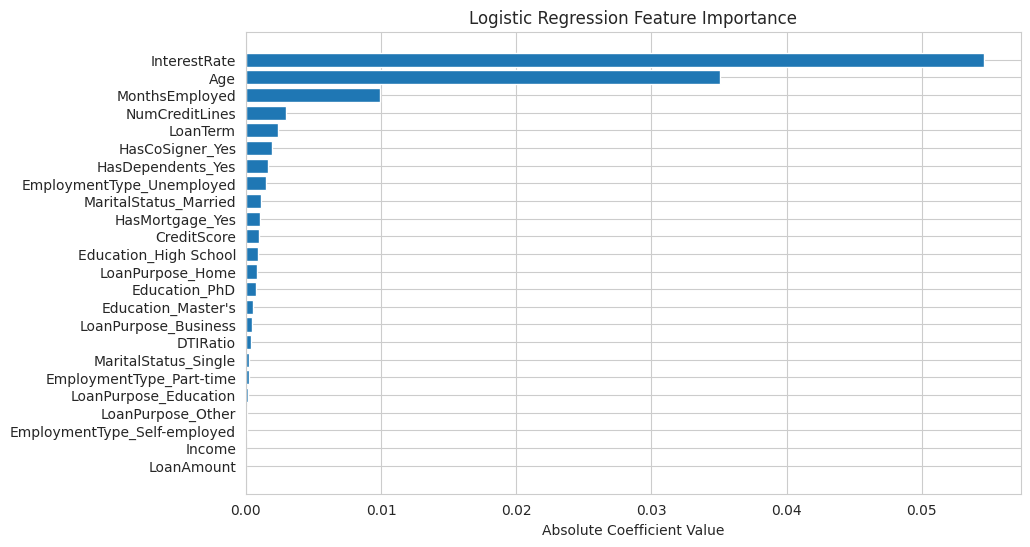

In [41]:
plt.figure(figsize=(10, 6))


plt.barh(
    feature_importance_log['feature'],
    feature_importance_log['Absolute_Coefficient']
)
plt.title('Logistic Regression Feature Importance')
plt.xlabel('Absolute Coefficient Value')
plt.gca().invert_yaxis()
plt.show()


# **Random Forest**

In [42]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest F1 Score: {f1_rf:.4f}")

Random Forest Accuracy: 0.8849
Random Forest F1 Score: 0.0104


# **Random Forest Feature Importance**

In [43]:
feature_importance_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(
    by='importance',
    ascending=False
)

feature_importance_rf

,feature,importance
0,Age,0.233990
1,Income,0.188544
6,InterestRate,0.164733
2,LoanAmount,0.117771
4,MonthsEmployed,0.098850
3,CreditScore,0.048633
8,DTIRatio,0.034293
5,NumCreditLines,0.013695
23,HasCoSigner_Yes,0.012642
7,LoanTerm,0.012154


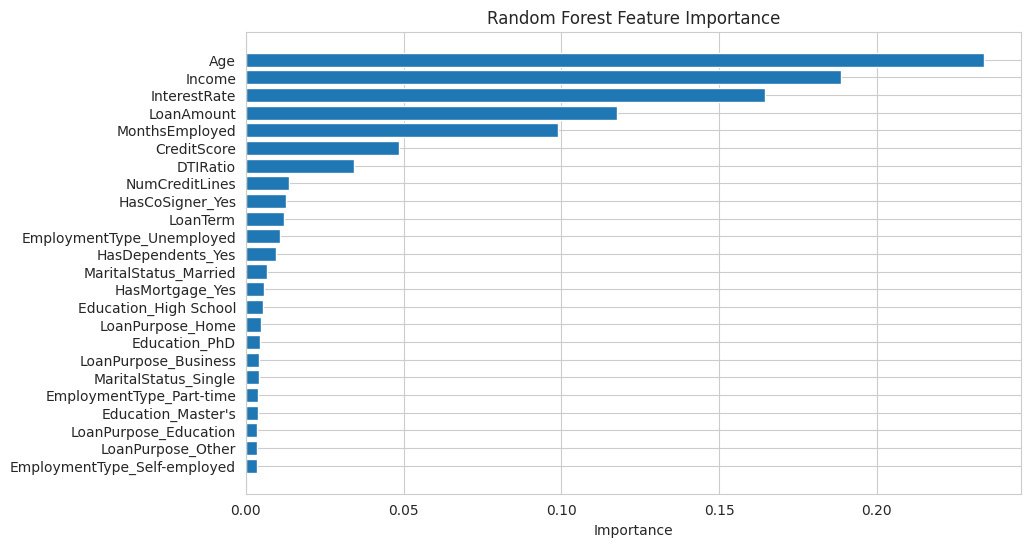

In [44]:
# Random Forest Feature Importance

feature_importance_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by='importance',
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_rf['feature'],
    feature_importance_rf['importance']
)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

In [45]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost F1 Score: {f1_xgb:.4f}")


XGBoost Accuracy: 0.8880
XGBoost F1 Score: 0.1304


# **XGBoost Feature Importance**

In [46]:
feature_importance_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(
    by='importance',
    ascending=False
)

feature_importance_xgb

,feature,importance
0,Age,0.156413
6,InterestRate,0.085120
1,Income,0.075540
2,LoanAmount,0.059456
23,HasCoSigner_Yes,0.057959
4,MonthsEmployed,0.056283
18,HasDependents_Yes,0.054912
14,EmploymentType_Unemployed,0.049045
15,MaritalStatus_Married,0.048601
13,EmploymentType_Self-employed,0.046574


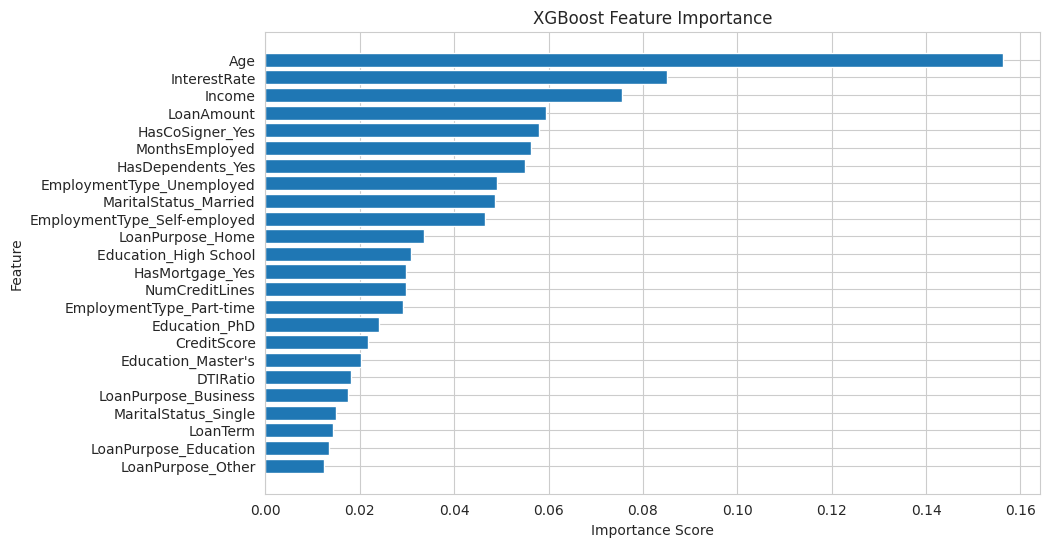

In [47]:
# Xgboost Feature Importance

feature_importance_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by='importance',
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_xgb['feature'],
    feature_importance_xgb['importance']
)

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.gca().invert_yaxis()
plt.show()

# **Compare All Three Models**

In [48]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_log_reg,
        accuracy_rf,
        accuracy_xgb
    ],
    'F1 Score': [
        f1_log_reg,
        f1_rf,
        f1_xgb
    ]
})

comparison

,Model,Accuracy,F1 Score
0,Logistic Regression,0.884903,0.024884
1,Random Forest,0.884923,0.010439
2,XGBoost,0.887958,0.130395


# **Visualize the Comparison**

Text(0, 0.5, 'Score')

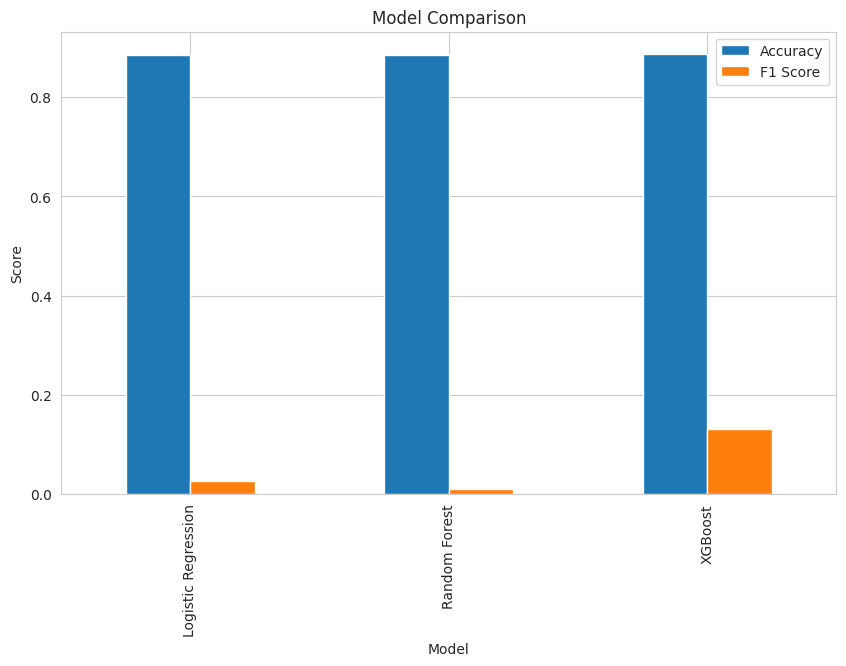

In [49]:
comparison.set_index('Model')[['Accuracy', 'F1 Score' ]].plot(
    kind='bar',
    title='Model Comparison',
    figsize=(10, 6)
)

plt.title('Model Comparison')
plt.xlabel('Model')
plt.ylabel('Score')

# **select the best model automatically**

In [50]:
best_model_name = comparison.sort_values(
    by='F1 Score',
    ascending=False
).iloc[0]['Model']

print(f"Best Model:", best_model_name
)

Best Model: XGBoost


# **Save the Best Model**

In [54]:
import joblib

if best_model_name == 'Logistic Regression':
    best_model = log_reg

elif best_model_name == 'Random Forest':
    best_model = rf_model

else:
     best_model_name = xgb_model

joblib.dump(best_model_name, "loan_default_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# **Streamlit Application**

# **app.py**

In [55]:
app_py_content = """
import streamlit as st
import pandas as pd
import joblib

# PAGE CONFIGURATION

st.set_page_config(
    page_title="Loan Default Prediction",
    page_icon="💳",
    layout="wide"
)

# LOAD MODEL

model = joblib.load("loan_default_model.pkl")

# CUSTOM CSS

st.markdown('''

 ''', unsafe_allow_html=True)

# SIDEBAR

with st.sidebar:

    st.image(
            "https://cdn-icon-png.flaticon.com/512/3135/3135715.png",
            width=150
    )

    st.title("📊 Project Overview")

    st.markdown('''
    ### Model is used

    - Logistic Regression
    - Random Forest
    - XGBoost

    ### Objective

    Predict whether a borrower is likely to default on a loan.

     ### Features

    -Real-time prediction
    -Risk probability
    -ML-powered decision support
    ''')

    st.divider()

    st.info(
        "Built with streamlit, Scikit-Learn and XGBooost."
    )

# HEADER

st.markdown(
    "💳 Loan Default Prediction System",
     unsafe_allow_html=True
)

st.markdown(
    "Machine Learning Powered Credit Risk Assessment Dashboard"
)

st.divider()

# INPUT SECTION

col1, col2, col3 = st.columns(3)

with col1:

    Age = st.number_input(
        "Age",
        min_value=18,
        max_value=100,
        value=30
    )

    Income = st.number_input(
        "Income",
        min_value=1000,
        value=5000
    )

    Loan_Amount = st.number_input(
          "Loan Amount",
          min_value=1000,
          value=10000
    )

with col2:

    CreditScore = st.number_input(
          "Credit Score",
          min_value=300,
          max_value=850,
          value=650
    )

    InterestRate = st.number_input(
          "Interest Rate",
          min_value=1.0,
          max_value=40.0,
          value=10.0
    )

    LoanTerm = st.number_input(
          "Loan Term (Months)",
          min_value=6,
          max_value=360,
          value=36
    )

with col3:

    MonthsEmployed = st.number_input(
          "Months Employed",
          min_value=0,
          value=24
    )

    NumCreditLines = st.number_input(
          "Number of Credit Lines",
          min_value=0,
          value=5
    )

    DTIRatio = st.number_input(
          "Debt-to-Income Ratio",
          min_value=0.0,
          max_value=1.0,
          value=0.30
    )

    # PREDICTION

    if st.button("🔍  Predict Loan Risk"):

    # Create a Dictionary for the input features
    input_data = {
            'Age': Age,
            'Income': Income,
            'LoanAmount': Loan_Amount,
            'CreditScore': CreditScore,
            'InterestRate': InterestRate,
            'LoanTerm': LoanTerm,
            'MonthsEmployed': MonthsEmployed,
            'NumCreditLines': NumCreditLines,
            'DTIRatio': DTIRatio
    }

    # Create a DaaFrame from the input dictionary
    input_data_df = pd.DataFrame([input_data])

    # Get the column names from the training data X
    # This list is obtained from the kernel state 's 'X' variable.
    expected_column_names = [
            'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
           'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
           'Education_High School',"Education_Master's", 'Education_PhD',
           'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single',
           'HasMortgage_Yes', 'HasDependents_Yes', 'LoanPurpose_Business',
           'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other',
           'HasCoSigner_Yes'
    ]

    # Create an empty DataFrame with the expected column names
    final_input_df = pd.DataFrame(columns=expected_column_names)


    # Populate the known numeric features
    for col in input_data_df.columns:
        if col in final_input_df.columns:
            final_input_df[col] = input_data_df[col]

    # Fill all other columns with (categorical one-hot encoded) with 0
    for col in final_input_df.columns:
        if col not in input_data_df.columns:
            final_input_df[col] = 0


   # Ensure the order of columns matches the training data 'X'
   final_input_df = final_input_df[expected_column_names]


   prediction = model.predict(final_input_df)[0]


   probability = model.predict_proba(
       final_input_df
   )[0][1]

   st.divider()

   st.subheader("Prediction Result")

   colA, colB = st.columns(2)

   with colA:

       if prediction == 1:

           st.error(
               f'''
               ⚠️HIGH DEFAULT RISK

               Probability of Default:
               {probability:.2%}
               '''
           )

       else:

           st.success(
               f'''
               ✅ LOW DEFAULT RISK

                Probability of Default:
                {probability:.2%}
                '''
           )

with colB:

           st.metric(
                "Default Probability",
                f"{probability:.2%}"
           )

           st.progress(float(probability))
           st.metric(
                "Risk Level",
                "High Risk" if prediction == 1 else "Low Risk"
           )

# FOOTER

st.divider()

st.caption(
     "Loan Default Prediction Dashboard | Machine Learning Project"
)
"""

with open("app.py", "w") as file:
    file.write(app_py_content)

print("app.py has been created successfully!")

app.py has been created successfully!


## **Generate requirement.txt**

In [53]:
import pkg_resources

# Get a list of installed packages and their versions
installed_packages = {d.project_name: d.version for d in pkg_resources.working_set}

required_packages = [
    'streamlit',
    'pandas',
    'joblib',
    'scikit-learn',
    'xgboost',
    'matplotlib',
    'seaborn'
]

# Create the requirements.txt content
requirements_content = []
for package in required_packages:
  if package in installed_packages:
    requirements_content.append(f"{package}=={installed_packages[package]}")
  else:
      print(f"Warning: package '{package}' not found in installed packages. Please ensure it's installed.")

# Write to requirements.txt file
with open ("requirements.txt", "w") as requirements_file:
    requirements_file.write("\n".join(requirements_content))

print("requirements.txt has been created successfully!")

requirements.txt has been created successfully!
